In [15]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath("C:/Users/pc/Desktop/Week 5_6/fraud-detection/src/"))

In [2]:
from src.data_loader import load_data
from src.eda import *


print('Functions imported successfully!')
print()

Functions imported successfully!



### Load Credit card Dataset

In [3]:
df = load_data('C:/Users/pc/Desktop/Week 5_6/fraud-detection/data/raw/creditcard.csv')
df.head()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Analysis and Preprocessing

Justification

- Drop columns when more than 50% of values are missing because they contain insufficient information and may introduce bias.

- Median imputation for numerical features is preferred over the mean because it is less affected by extreme values (common in insurance and financial datasets).

- Mode imputation for categorical features preserves the most common category and maintains valid category values.

### # Data Cleaning

In [4]:
# Handle missing values
df_clean = handle_missing_values(df, missing_threshold=0.5)


Missing values after treatment:
0


In [5]:
# Remove duplicates
df_clean = remove_duplicates(df)

Number of duplicate rows: 1081
Shape after removing duplicates: (283726, 31)


In [23]:
df = auto_correct_data_types(df_clean)

Updated Data Types:
time        Int64
v1        Float64
v2        Float64
v3        Float64
v4        Float64
v5        Float64
v6        Float64
v7        Float64
v8        Float64
v9        Float64
v10       Float64
v11       Float64
v12       Float64
v13       Float64
v14       Float64
v15       Float64
v16       Float64
v17       Float64
v18       Float64
v19       Float64
v20       Float64
v21       Float64
v22       Float64
v23       Float64
v24       Float64
v25       Float64
v26       Float64
v27       Float64
v28       Float64
amount    Float64
class       Int64
dtype: object


### # Exploratory Data Analysis

#### -	Univariate distributions of key variables

In [6]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

print("Numeric columns:", numeric_cols)

Numeric columns: ['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class']



Variable: time
count        283726.0
mean       94811.0776
std      47481.047891
min               0.0
25%          54204.75
50%           84692.5
75%          139298.0
max          172792.0
Name: time, dtype: Float64


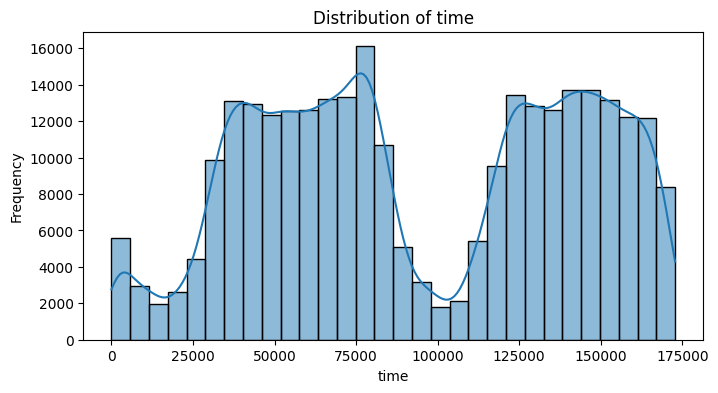


Variable: v1
count    283726.0
mean     0.005917
std      1.948026
min     -56.40751
25%     -0.915951
50%      0.020384
75%      1.316068
max       2.45493
Name: v1, dtype: Float64


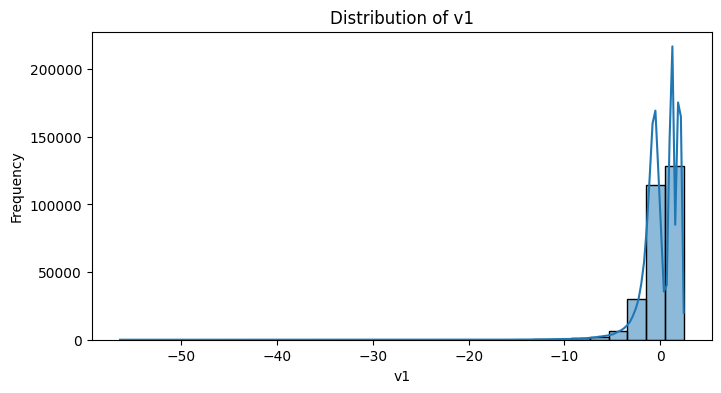


Variable: v2
count     283726.0
mean     -0.004135
std       1.646703
min     -72.715728
25%      -0.600321
50%       0.063949
75%       0.800283
max      22.057729
Name: v2, dtype: Float64


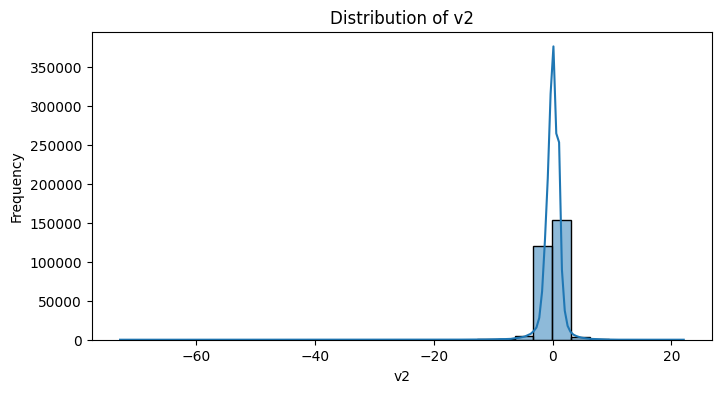


Variable: v3
count     283726.0
mean      0.001613
std       1.508682
min     -48.325589
25%      -0.889682
50%       0.179963
75%        1.02696
max       9.382558
Name: v3, dtype: Float64


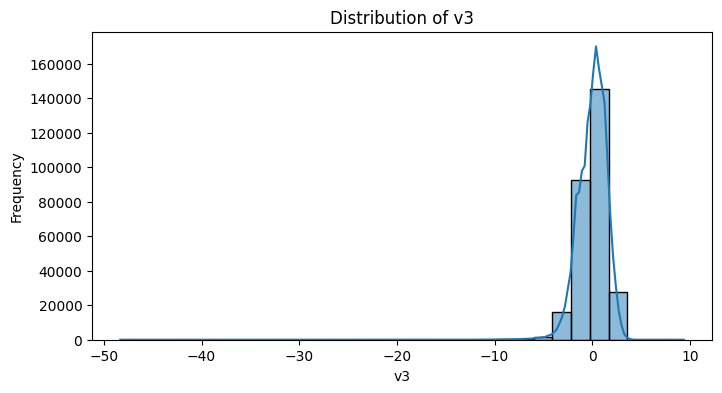


Variable: v4
count     283726.0
mean     -0.002966
std       1.414184
min      -5.683171
25%      -0.850134
50%      -0.022248
75%       0.739647
max      16.875344
Name: v4, dtype: Float64


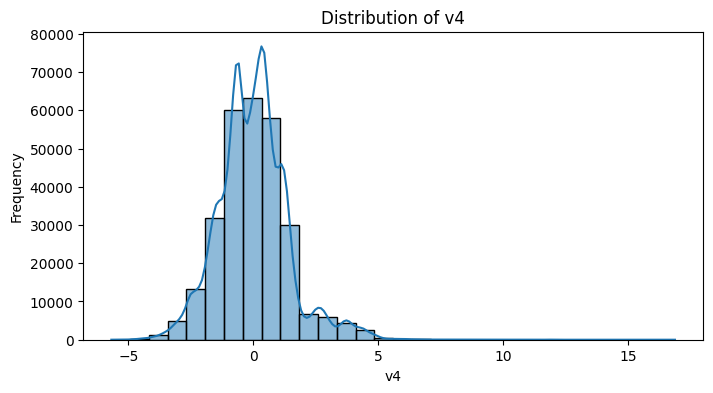


Variable: v5
count      283726.0
mean       0.001828
std        1.377008
min     -113.743307
25%        -0.68983
50%       -0.053468
75%        0.612218
max       34.801666
Name: v5, dtype: Float64


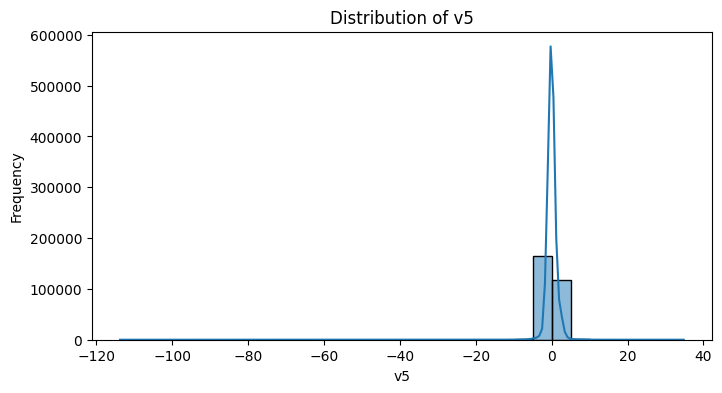


Variable: v6
count     283726.0
mean     -0.001139
std       1.331931
min     -26.160506
25%      -0.769031
50%      -0.275168
75%       0.396792
max      73.301626
Name: v6, dtype: Float64


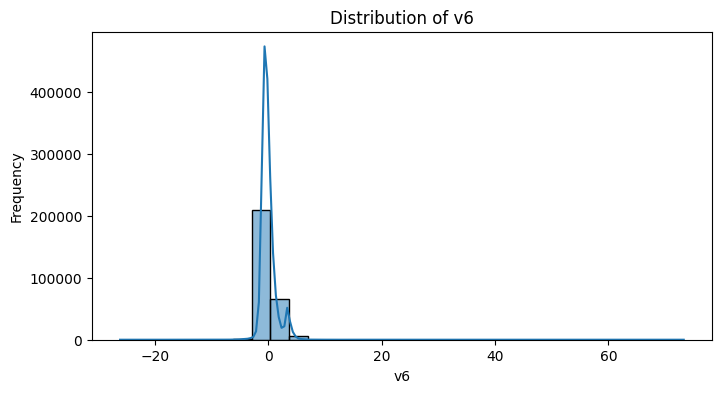


Variable: v7
count      283726.0
mean       0.001801
std        1.227664
min      -43.557242
25%       -0.552509
50%        0.040859
75%        0.570474
max      120.589494
Name: v7, dtype: Float64


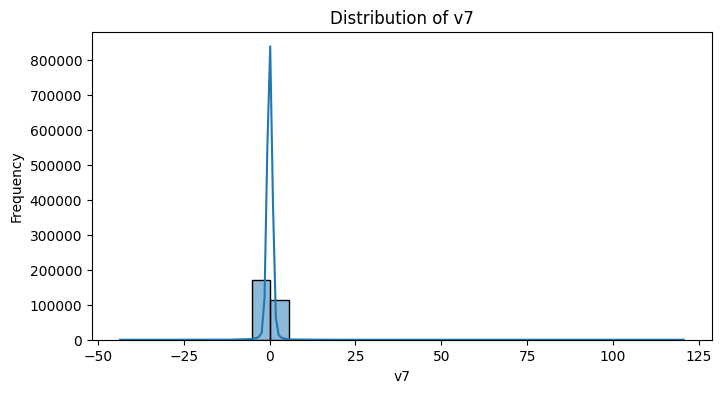


Variable: v8
count     283726.0
mean     -0.000854
std       1.179054
min     -73.216718
25%      -0.208828
50%       0.021898
75%       0.325704
max      20.007208
Name: v8, dtype: Float64


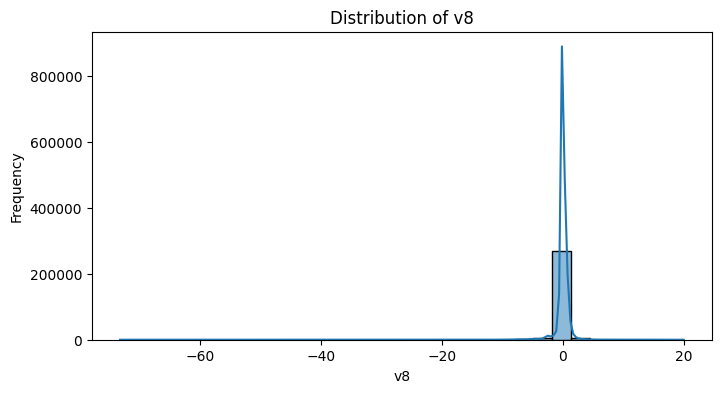


Variable: v9
count     283726.0
mean     -0.001596
std       1.095492
min     -13.434066
25%      -0.644221
50%      -0.052596
75%       0.595977
max      15.594995
Name: v9, dtype: Float64


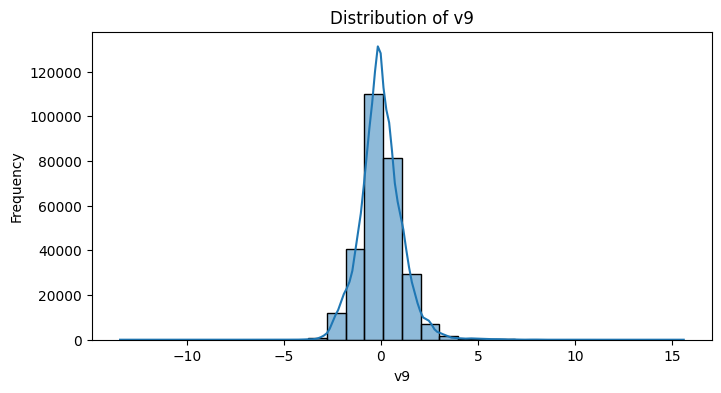


Variable: v10
count     283726.0
mean     -0.001441
std       1.076407
min     -24.588262
25%      -0.535578
50%      -0.093237
75%       0.453619
max      23.745136
Name: v10, dtype: Float64


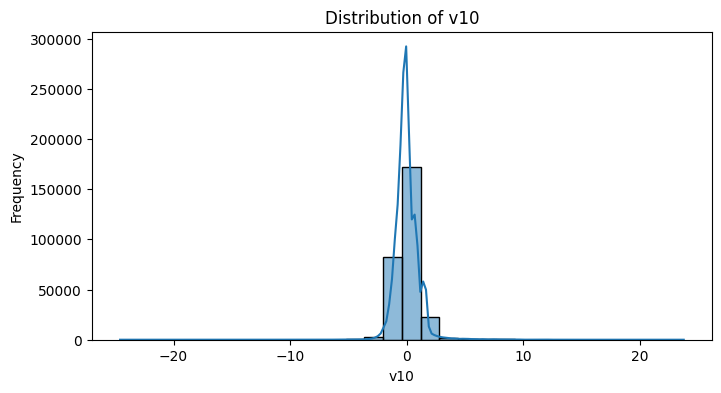


Variable: v11
count     283726.0
mean      0.000202
std        1.01872
min      -4.797473
25%      -0.761649
50%      -0.032306
75%       0.739579
max      12.018913
Name: v11, dtype: Float64


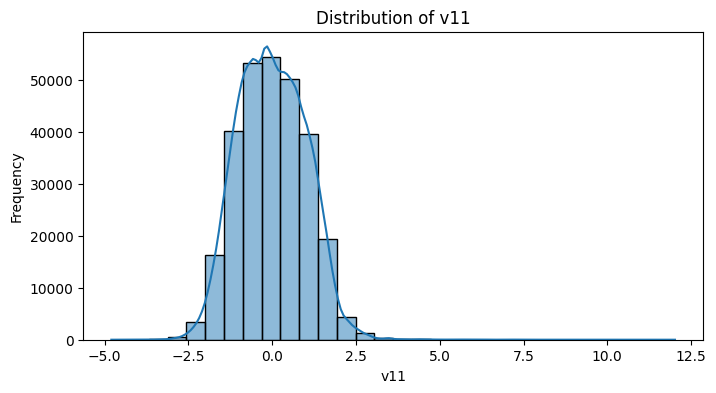


Variable: v12
count     283726.0
mean     -0.000715
std       0.994674
min     -18.683715
25%      -0.406198
50%       0.139072
75%       0.616976
max       7.848392
Name: v12, dtype: Float64


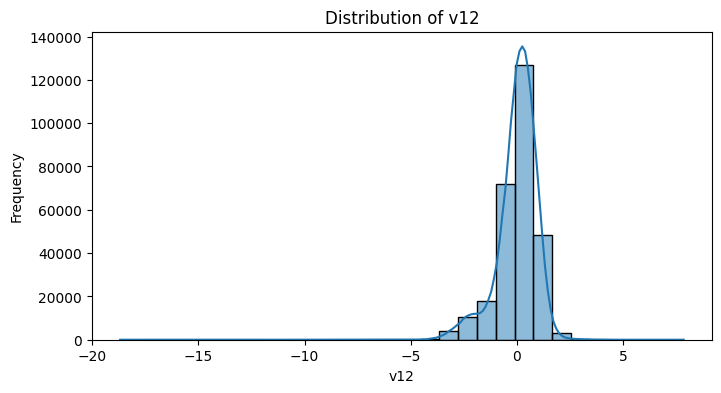


Variable: v13
count    283726.0
mean     0.000603
std       0.99543
min     -5.791881
25%     -0.647862
50%     -0.012927
75%      0.663178
max      7.126883
Name: v13, dtype: Float64


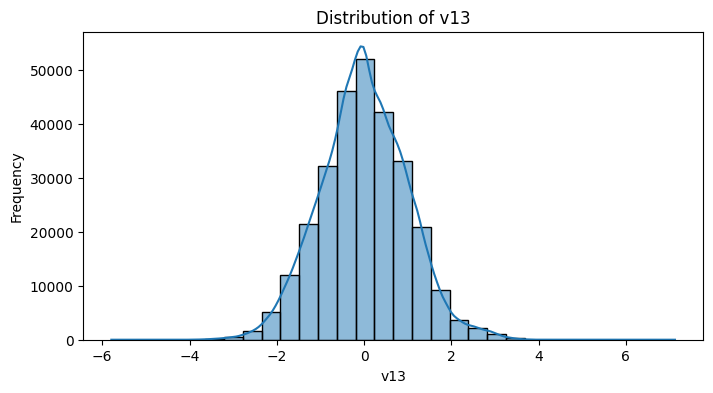


Variable: v14
count     283726.0
mean      0.000252
std       0.952215
min     -19.214325
25%      -0.425732
50%       0.050209
75%       0.492336
max      10.526766
Name: v14, dtype: Float64


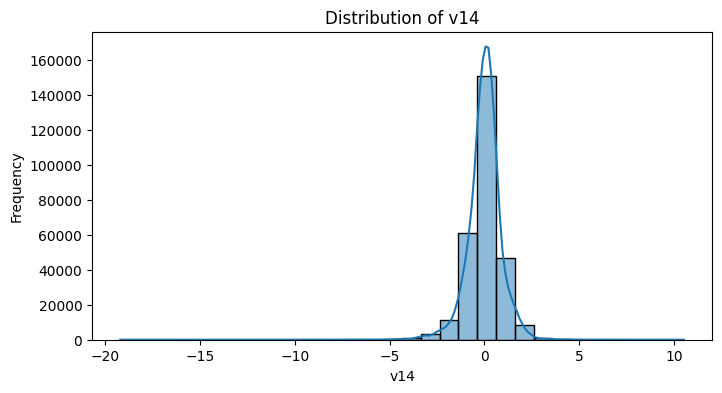


Variable: v15
count    283726.0
mean     0.001043
std      0.914894
min     -4.498945
25%     -0.581452
50%      0.049299
75%      0.650104
max      8.877742
Name: v15, dtype: Float64


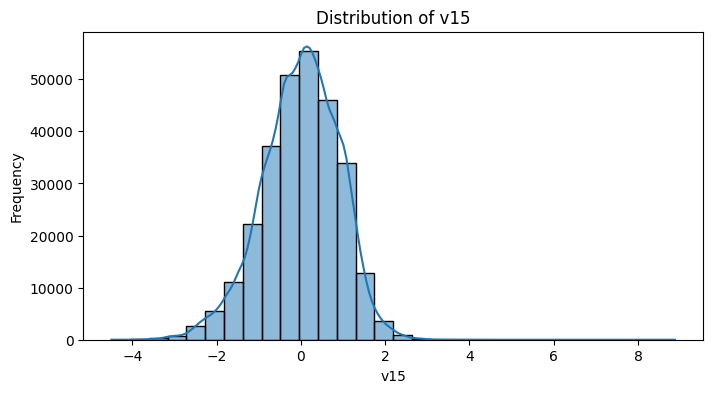


Variable: v16
count     283726.0
mean      0.001162
std       0.873696
min     -14.129855
25%       -0.46686
50%       0.067119
75%       0.523512
max      17.315112
Name: v16, dtype: Float64


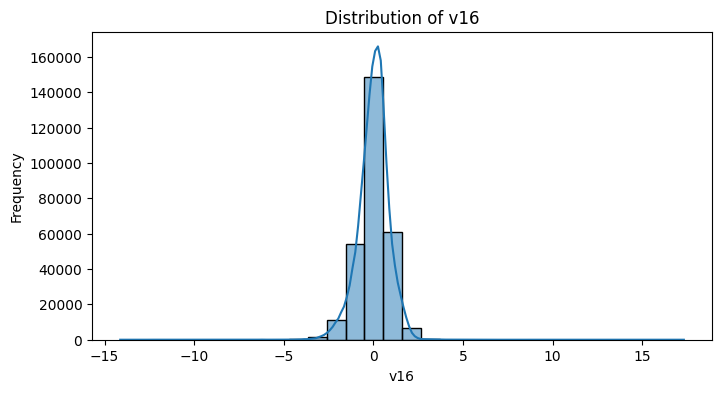


Variable: v17
count     283726.0
mean       0.00017
std       0.842507
min     -25.162799
25%      -0.483928
50%      -0.065867
75%       0.398972
max       9.253526
Name: v17, dtype: Float64


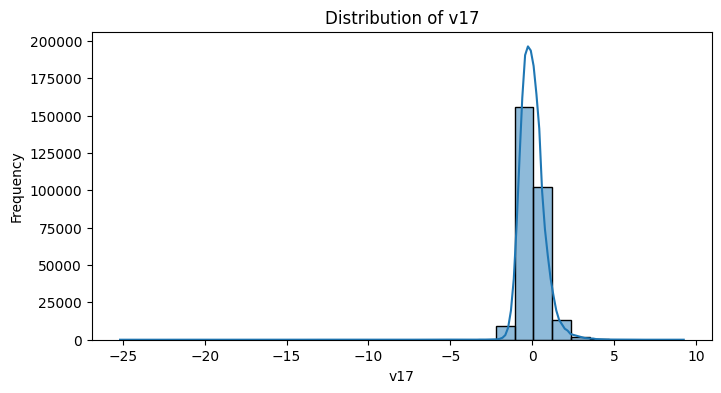


Variable: v18
count    283726.0
mean     0.001515
std      0.837378
min     -9.498746
25%     -0.498014
50%     -0.002142
75%      0.501956
max      5.041069
Name: v18, dtype: Float64


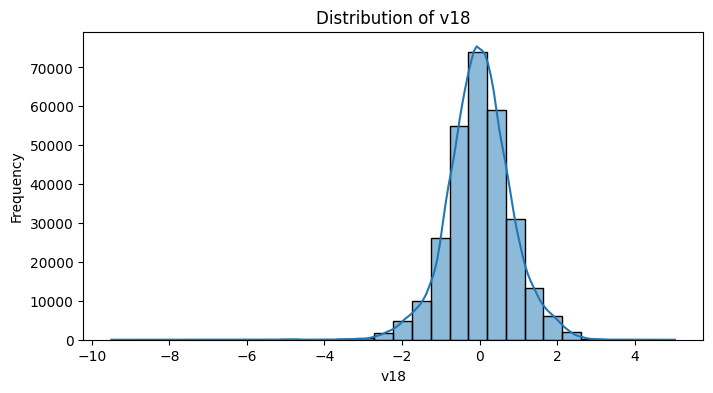


Variable: v19
count    283726.0
mean    -0.000264
std      0.813379
min     -7.213527
25%     -0.456289
50%      0.003367
75%      0.458508
max      5.591971
Name: v19, dtype: Float64


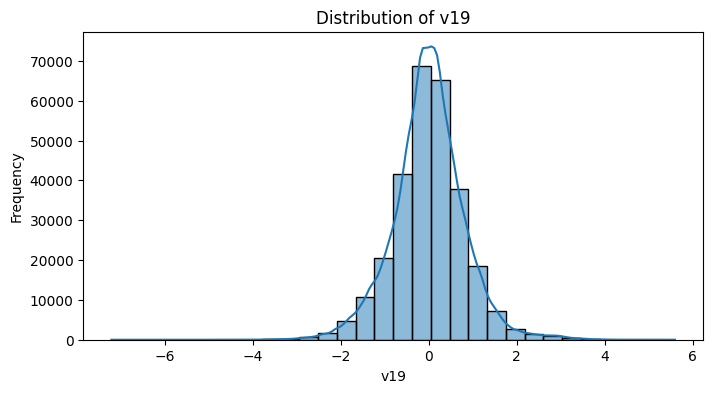


Variable: v20
count     283726.0
mean      0.000187
std       0.769984
min      -54.49772
25%      -0.211469
50%      -0.062353
75%       0.133207
max      39.420904
Name: v20, dtype: Float64


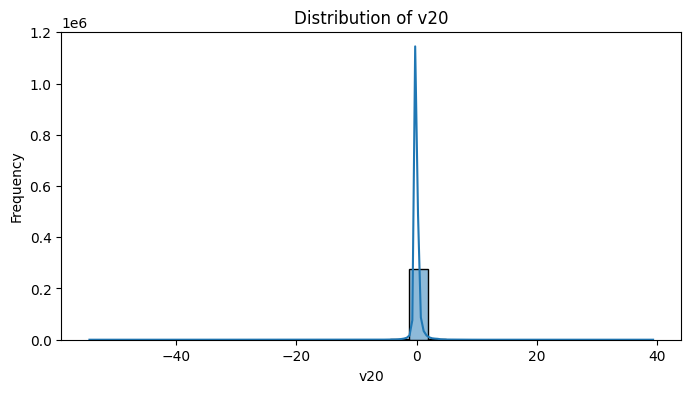


Variable: v21
count     283726.0
mean     -0.000371
std       0.723909
min     -34.830382
25%      -0.228305
50%      -0.029441
75%       0.186194
max      27.202839
Name: v21, dtype: Float64


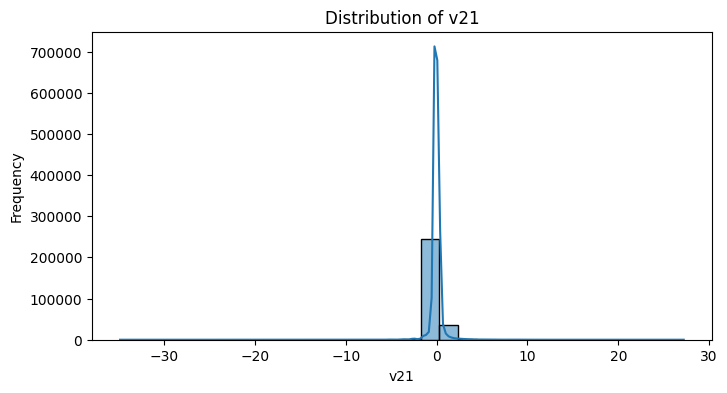


Variable: v22
count     283726.0
mean     -0.000015
std        0.72455
min     -10.933144
25%        -0.5427
50%       0.006675
75%       0.528245
max       10.50309
Name: v22, dtype: Float64


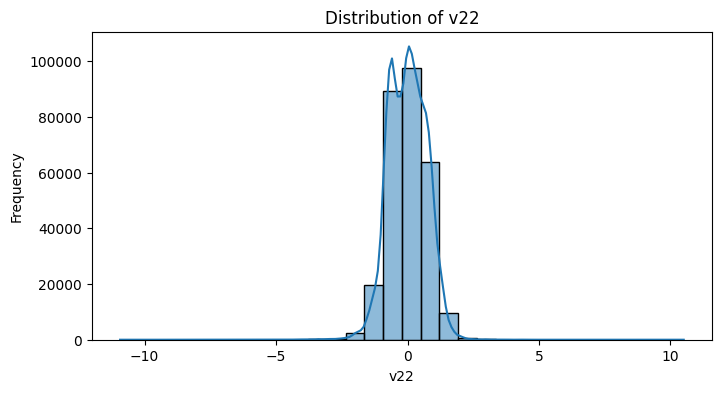


Variable: v23
count     283726.0
mean      0.000198
std       0.623702
min     -44.807735
25%      -0.161703
50%      -0.011159
75%       0.147748
max      22.528412
Name: v23, dtype: Float64


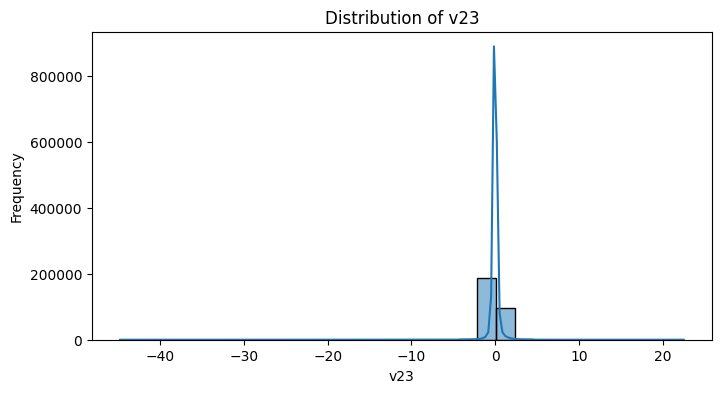


Variable: v24
count    283726.0
mean     0.000214
std      0.605627
min     -2.836627
25%     -0.354453
50%      0.041016
75%      0.439738
max      4.584549
Name: v24, dtype: Float64


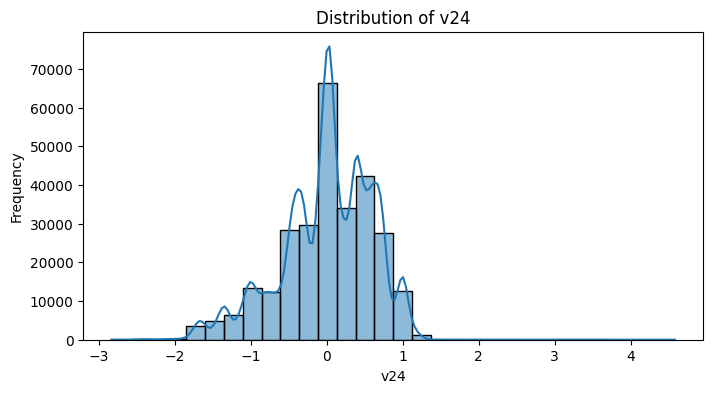


Variable: v25
count     283726.0
mean     -0.000232
std        0.52122
min     -10.295397
25%      -0.317485
50%       0.016278
75%       0.350667
max       7.519589
Name: v25, dtype: Float64


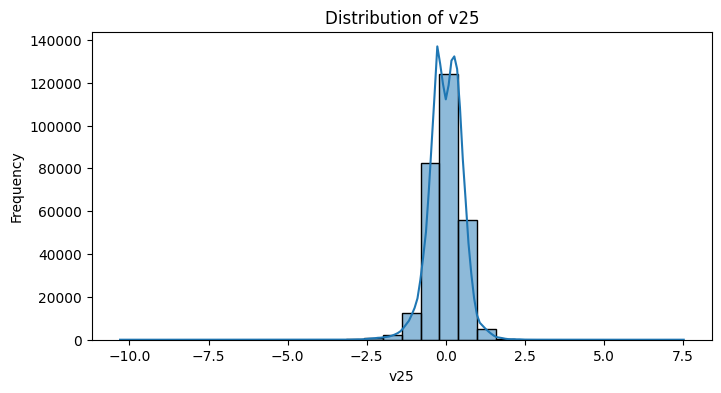


Variable: v26
count    283726.0
mean     0.000149
std      0.482053
min     -2.604551
25%     -0.326763
50%     -0.052172
75%      0.240261
max      3.517346
Name: v26, dtype: Float64


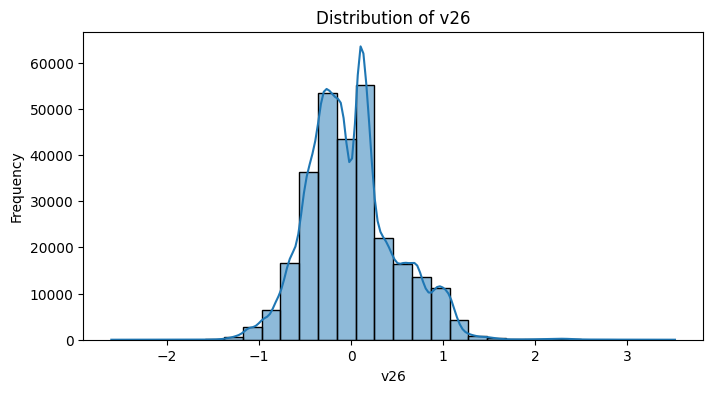


Variable: v27
count     283726.0
mean      0.001763
std       0.395744
min     -22.565679
25%      -0.070641
50%       0.001479
75%       0.091208
max      31.612198
Name: v27, dtype: Float64


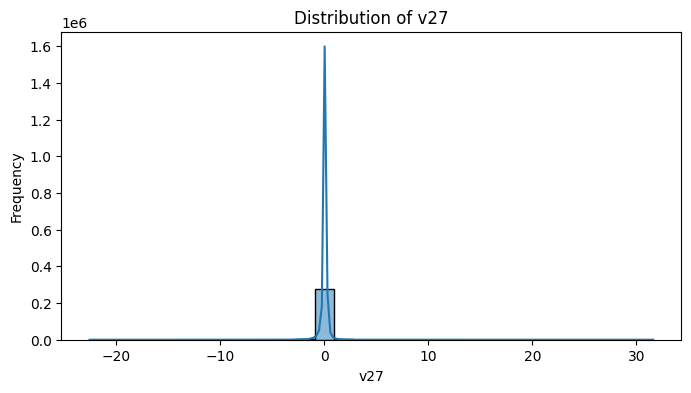


Variable: v28
count     283726.0
mean      0.000547
std       0.328027
min     -15.430084
25%      -0.052818
50%       0.011288
75%       0.078276
max      33.847808
Name: v28, dtype: Float64


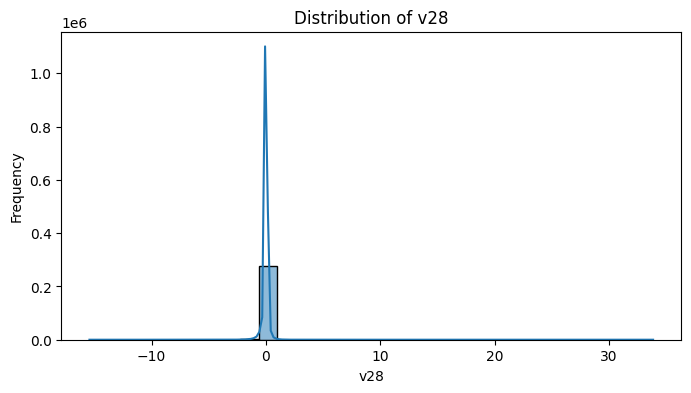


Variable: amount
count      283726.0
mean      88.472687
std      250.399437
min             0.0
25%             5.6
50%            22.0
75%           77.51
max        25691.16
Name: amount, dtype: Float64


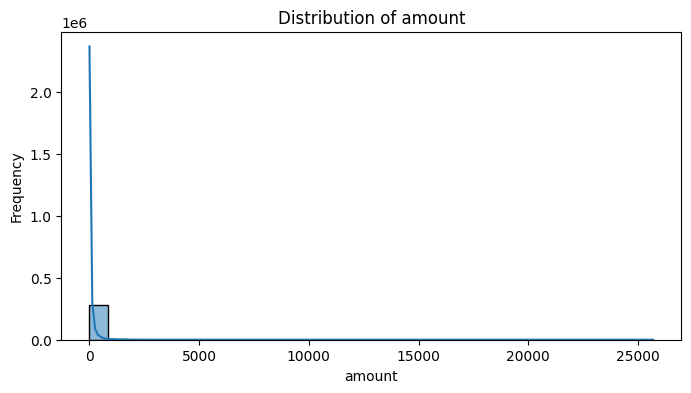


Variable: class
count    283726.0
mean     0.001667
std      0.040796
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           1.0
Name: class, dtype: Float64


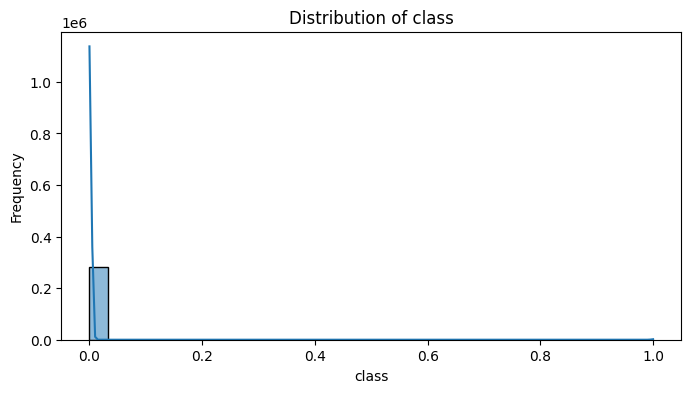

In [8]:
univariate_analysis(df, numeric_cols)

In [9]:
df.columns

Index(['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10',
       'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20',
       'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount',
       'class'],
      dtype='str')


time vs class
Correlation: -0.0124


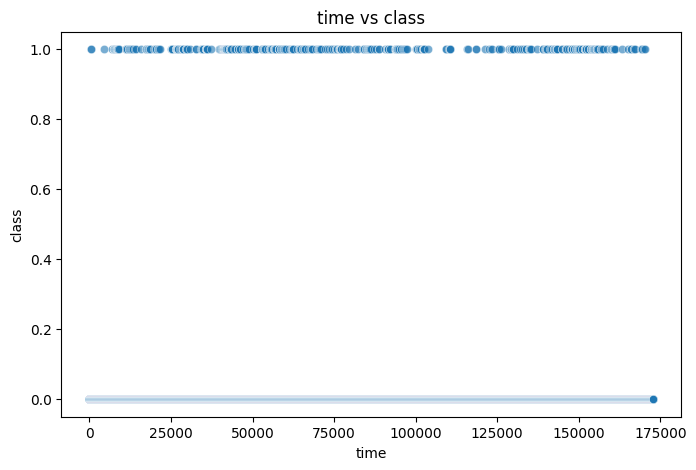


v1 vs class
Correlation: -0.0945


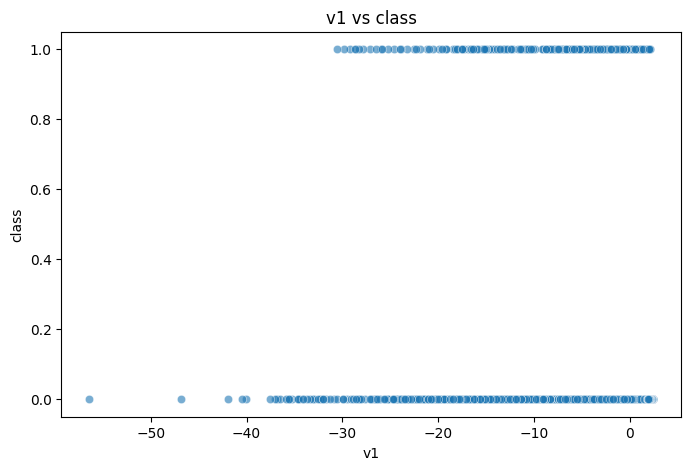


v2 vs class
Correlation: 0.0846


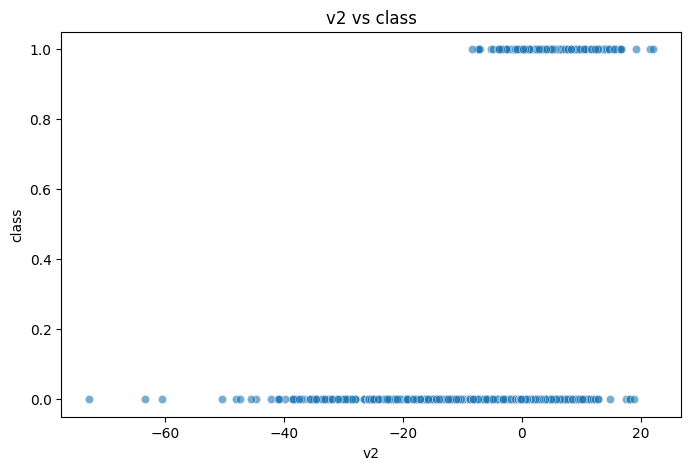


v3 vs class
Correlation: -0.1823


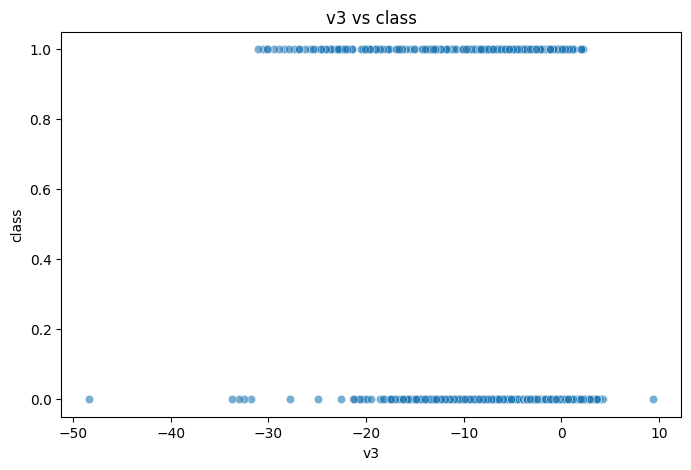


v4 vs class
Correlation: 0.1293


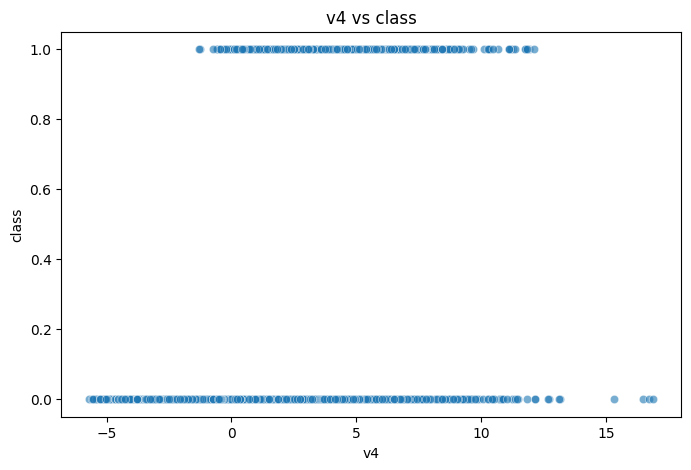


v5 vs class
Correlation: -0.0878


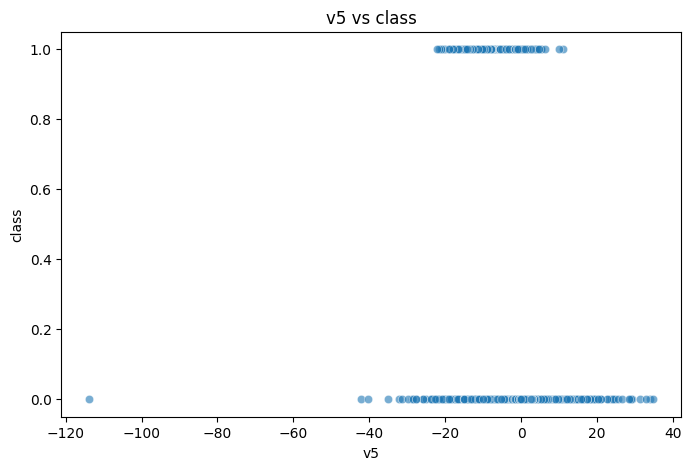


v6 vs class
Correlation: -0.0439


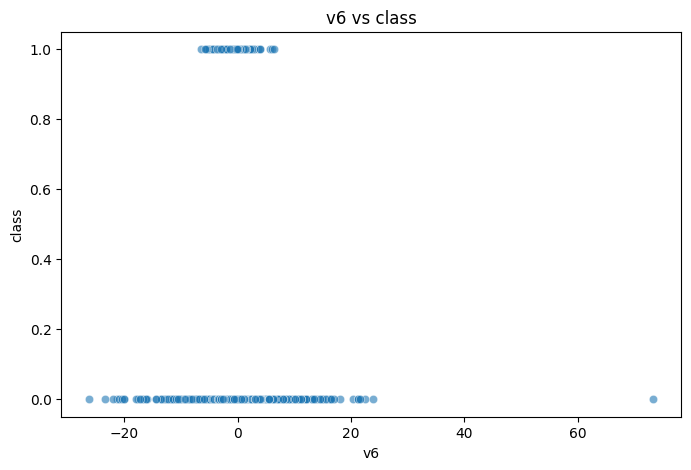


v7 vs class
Correlation: -0.1723


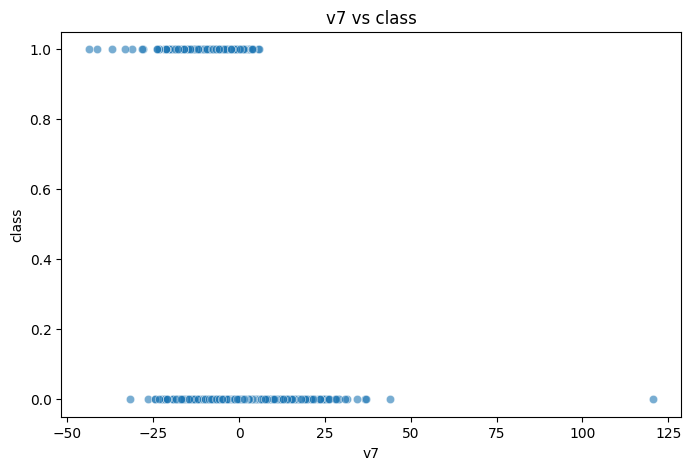


v8 vs class
Correlation: 0.0331


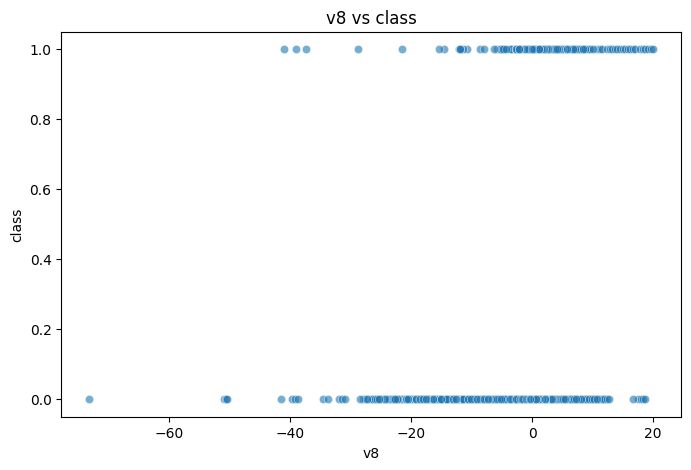


v9 vs class
Correlation: -0.0940


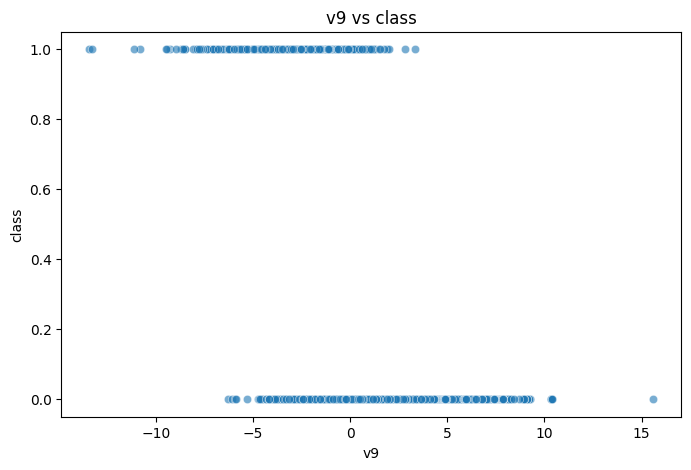


v10 vs class
Correlation: -0.2070


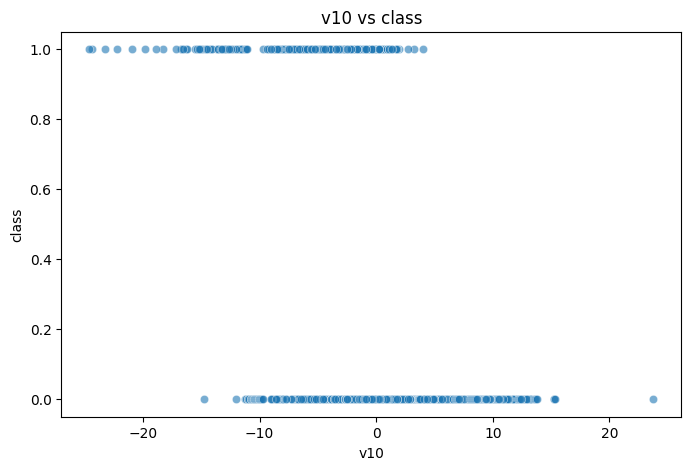


v11 vs class
Correlation: 0.1491


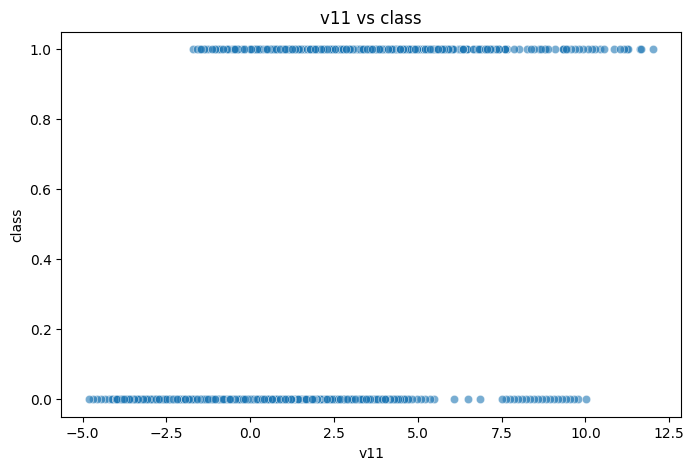


v12 vs class
Correlation: -0.2507


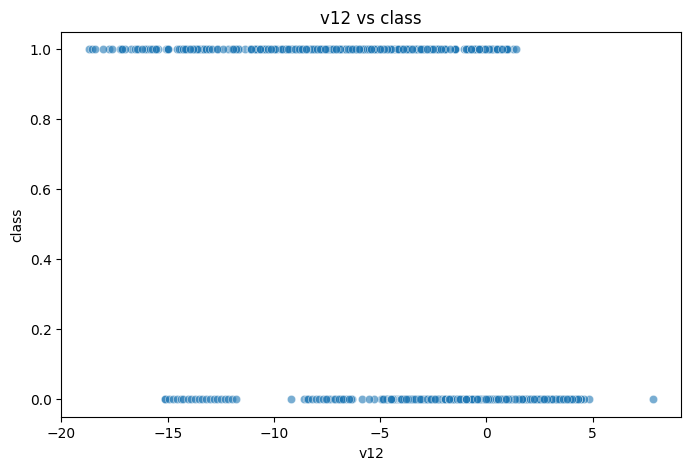


v13 vs class
Correlation: -0.0039


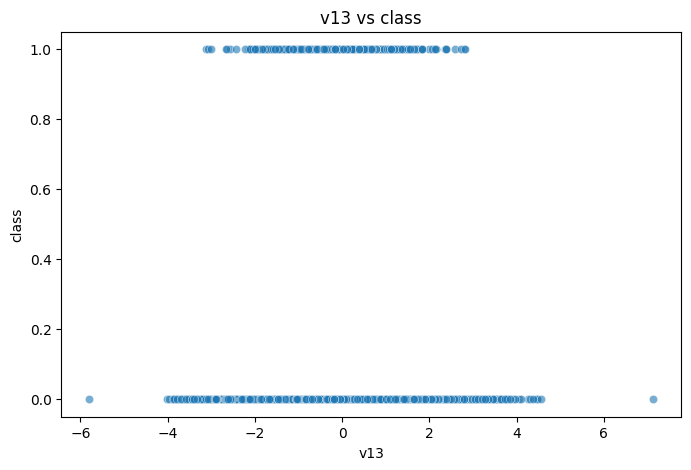


v14 vs class
Correlation: -0.2934


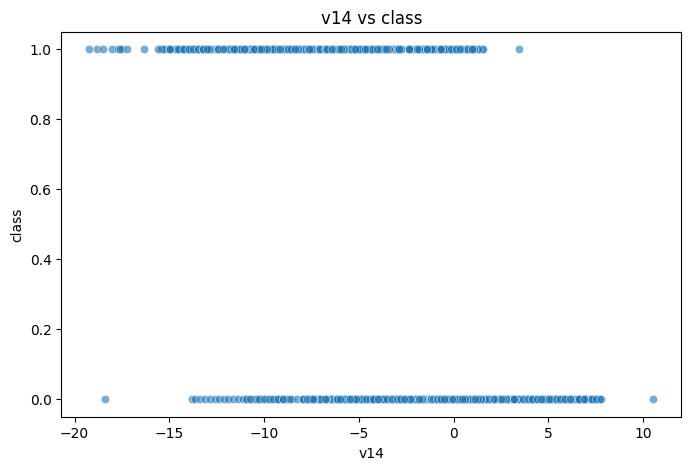


v15 vs class
Correlation: -0.0033


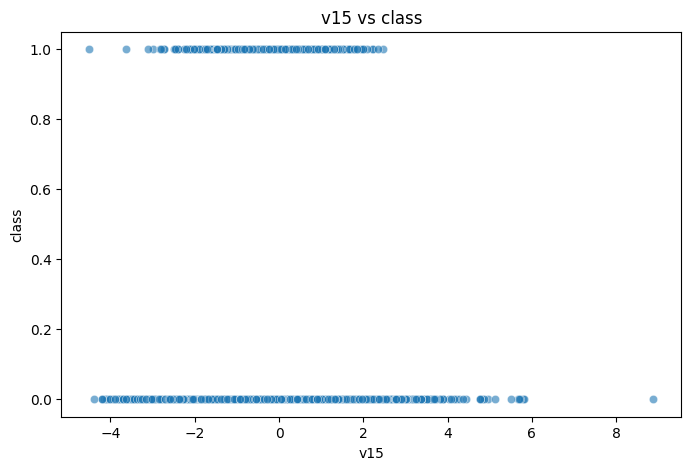


v16 vs class
Correlation: -0.1872


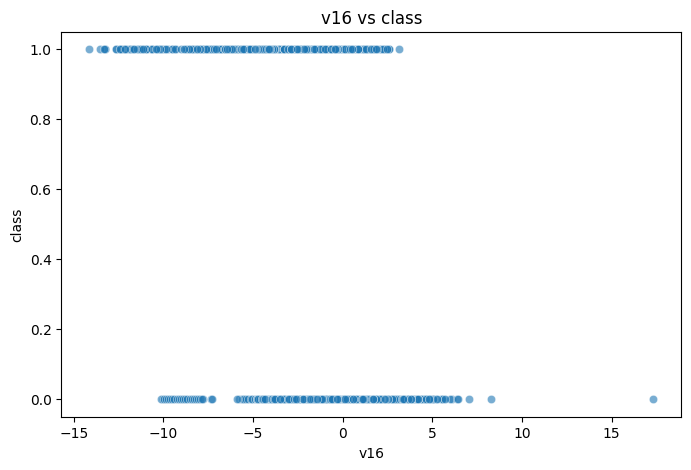


v17 vs class
Correlation: -0.3135


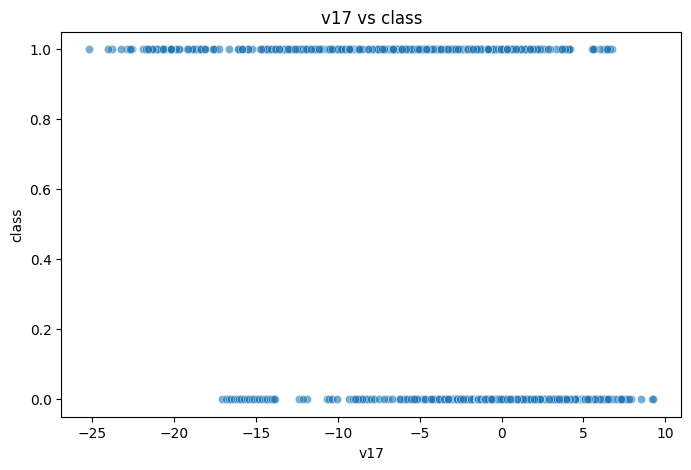


v18 vs class
Correlation: -0.1053


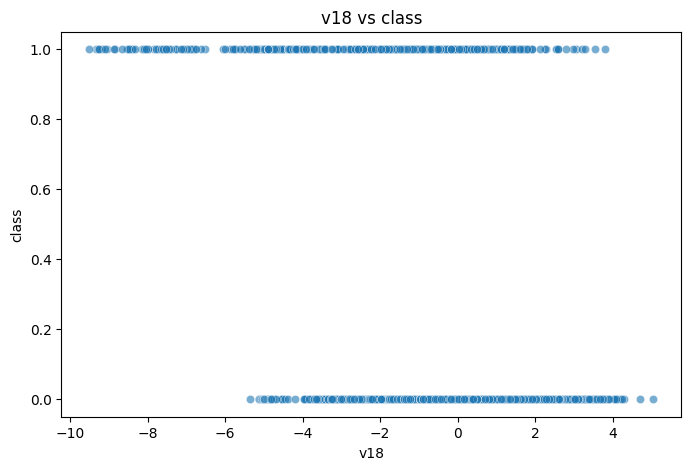


v19 vs class
Correlation: 0.0336


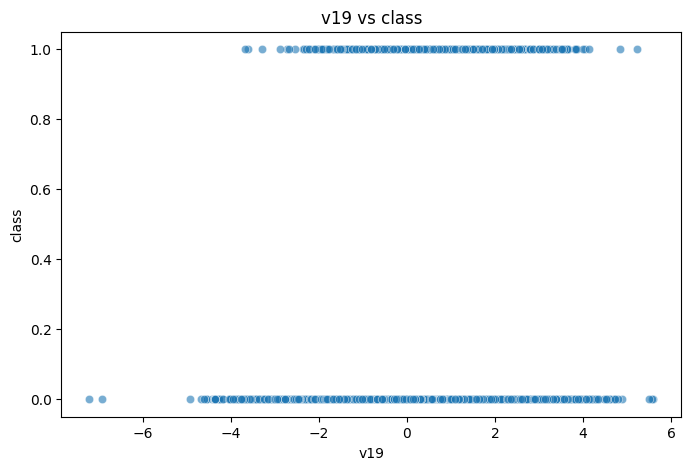


v20 vs class
Correlation: 0.0215


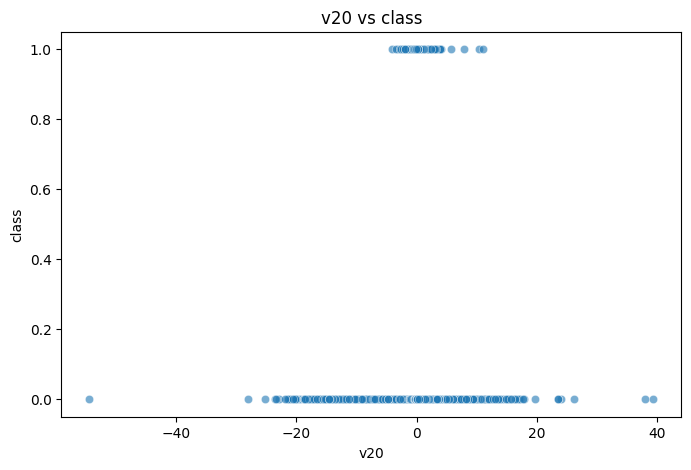


v21 vs class
Correlation: 0.0264


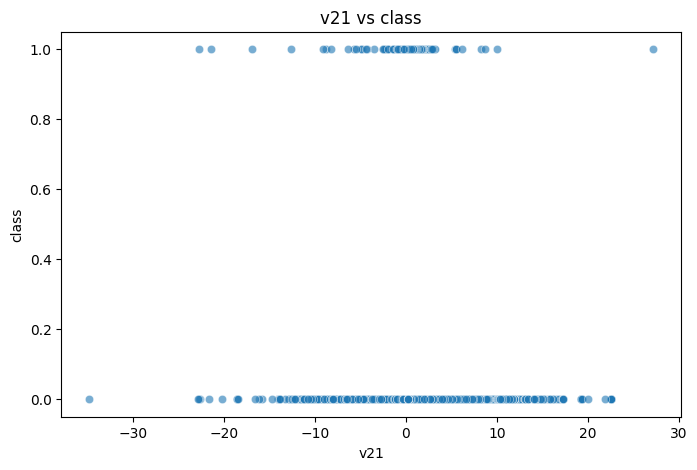


v22 vs class
Correlation: 0.0049


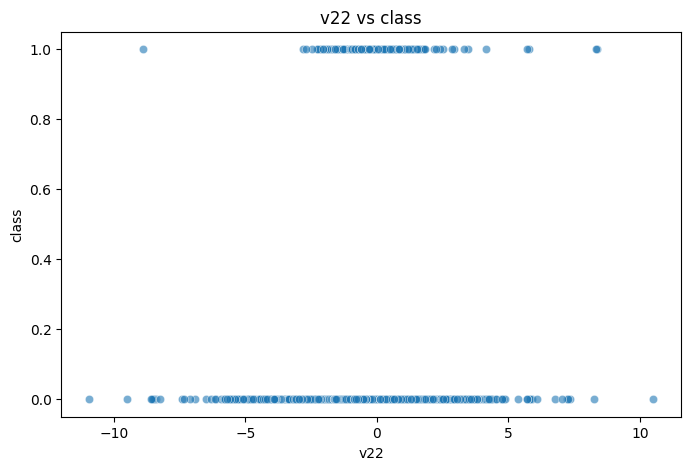


v23 vs class
Correlation: -0.0063


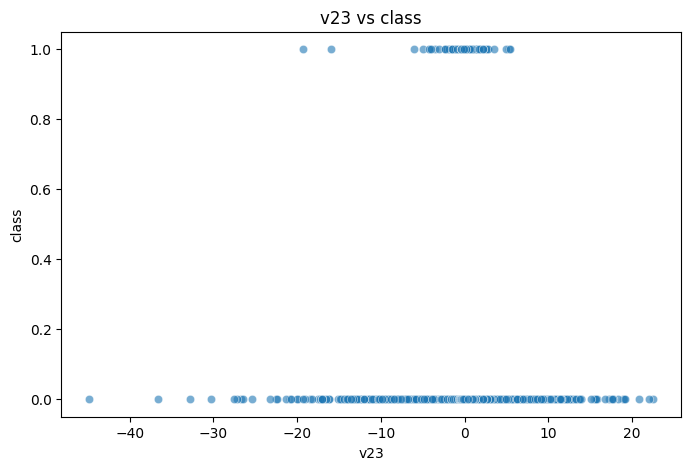


v24 vs class
Correlation: -0.0072


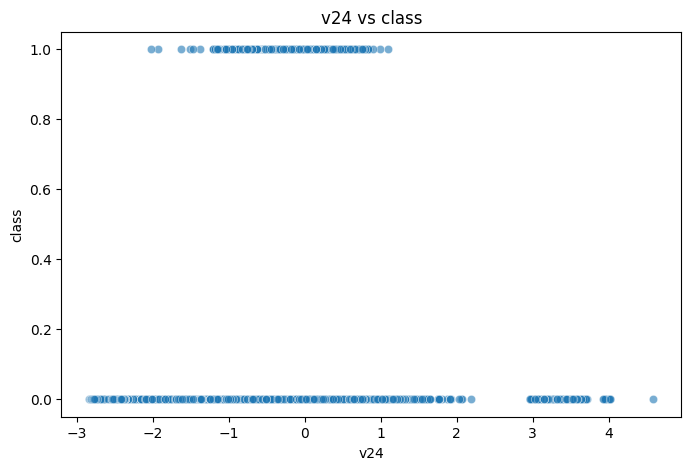


v25 vs class
Correlation: 0.0032


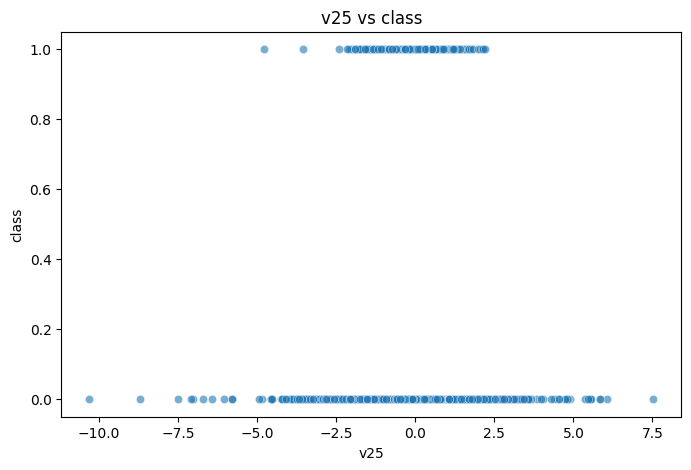


v26 vs class
Correlation: 0.0043


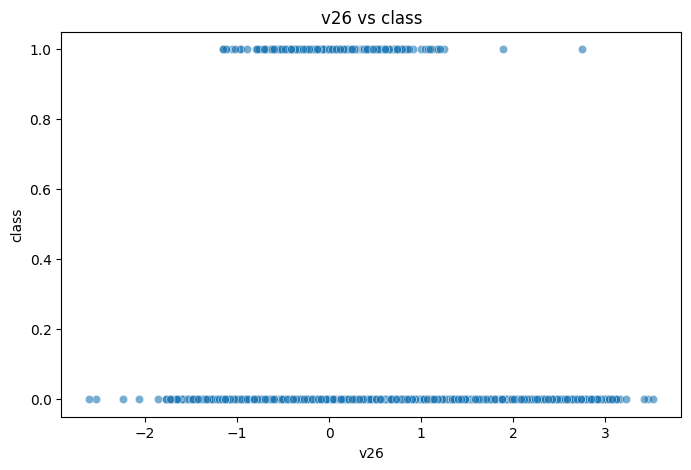


v27 vs class
Correlation: 0.0219


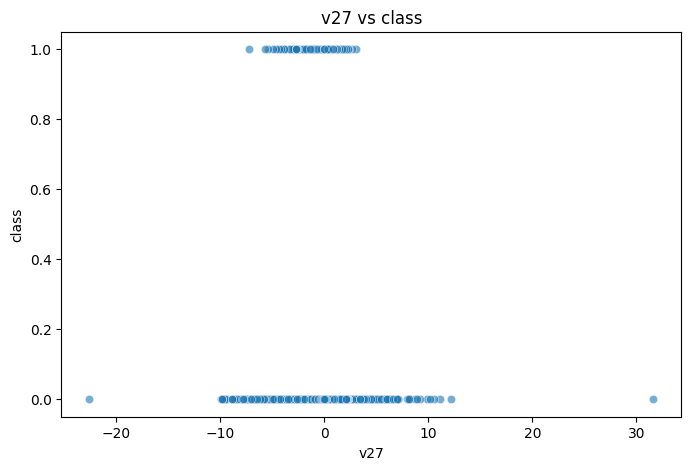


v28 vs class
Correlation: 0.0097


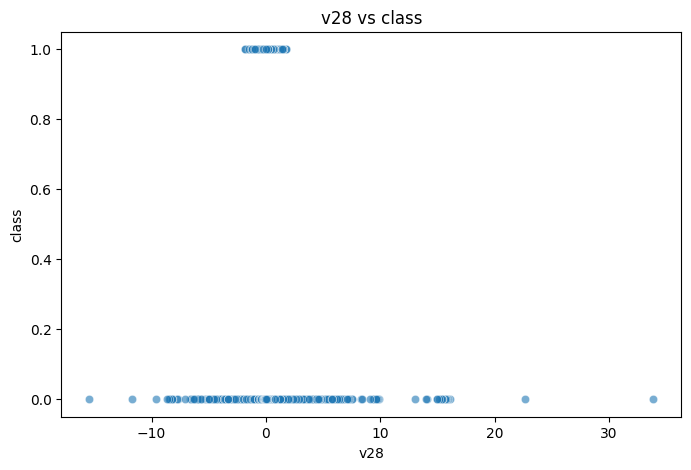


amount vs class
Correlation: 0.0058


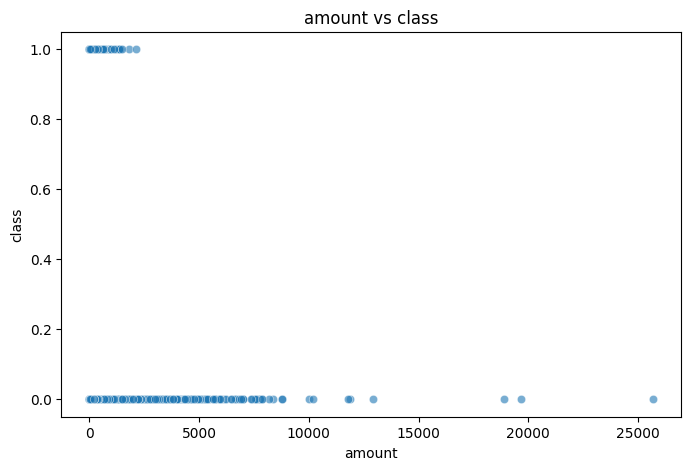

In [8]:
bivariate_analysis(df, target="class")

In [24]:
corr_table = feature_target_correlation(
    df,
    target="class"
)

print(corr_table)

   Feature  Correlation
0      v17    -0.313498
1      v14    -0.293375
2      v12    -0.250711
3      v10    -0.206971
4      v16    -0.187186
5       v3    -0.182322
6       v7    -0.172347
7      v11     0.149067
8       v4     0.129326
9      v18    -0.105340
10      v1    -0.094486
11      v9    -0.094021
12      v5    -0.087812
13      v2     0.084624
14      v6    -0.043915
15     v19     0.033631
16      v8     0.033068
17     v21     0.026357
18     v27     0.021892
19     v20     0.021486
20    time    -0.012359
21     v28     0.009682
22     v24    -0.007210
23     v23    -0.006333
24  amount     0.005777
25     v22     0.004887
26     v26     0.004265
27     v13    -0.003897
28     v15    -0.003300
29     v25     0.003202



Class Distribution for 'class'
----------------------------------------
        Count  Percentage (%)
class                        
0      284315           99.83
1         492            0.17

Imbalance Ratio: 577.88:1


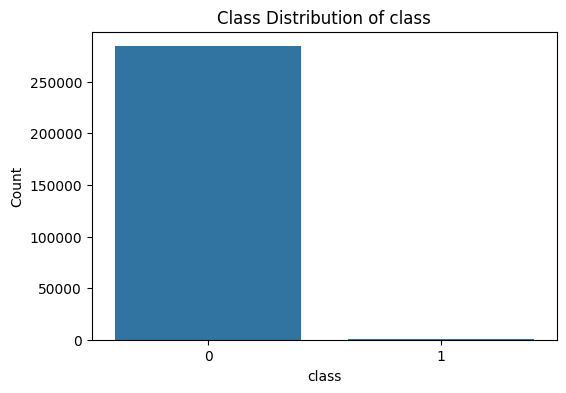

        Count  Percentage (%)
class                        
0      284315           99.83
1         492            0.17


In [7]:
claim_distribution = quantify_class_imbalance(
    df,
    target="class"
)

print(claim_distribution)

### # Data Transformation

In [8]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "user_id"]

print("Numeric columns:", numeric_cols)

Numeric columns: ['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class']


In [9]:
df_scaled, scaler = scale_numerical_features(
    df,
    columns=numeric_cols,
    method="standard"
)

Scaled columns using standard scaler:
['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class']


In [10]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:", categorical_cols)

Categorical columns: []


In [11]:
df_encoded = one_hot_encode_features(
    df,
    columns=categorical_cols,
    drop_first=True
)

Encoding columns: []


### # Handle Class Imbalance

In [12]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [13]:
X_train_balanced, y_train_balanced = apply_smote_to_training_set(
    X_train,
    y_train
)

Original class distribution:
class
0    227451
1       394
Name: count, dtype: int64

Resampled class distribution:
class
0    227451
1    227451
Name: count, dtype: int64


In [14]:
# To Save the processed data to a new csv file
output_file_path = "C:/Users/pc/Desktop/Week 5_6/fraud-detection/data/processed/Creditcard_processed.csv"
df_encoded.to_csv(output_file_path, index=False)